# Visualize EMD results for each comparison

We will visualize the signed EMD results for each comparison as violin and stacked bar plots.

In [1]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(arrow))

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘tidyr’ was built under R version 4.2.3”
Warning message:
“package ‘arrow’ was built under R version 4.2.3”


## Set output directory and constants for figures

In [2]:
output_dir <- "./emd_figures"
if (!dir.exists(output_dir)) {
    dir.create(output_dir, recursive = TRUE)
}

In [3]:
emd_thresholds <- read.csv("emd_results/emd_thresholds.csv")

# Assign each threshold to a separate variable
emd_lower_threshold_healthy_v_failing_drug_x <- emd_thresholds$EMD_threshold_lower[1]
emd_upper_threshold_healthy_v_failing_drug_x <- emd_thresholds$EMD_threshold_upper[1]
emd_lower_threshold_failing_v_failing_drug_x <- emd_thresholds$EMD_threshold_lower[2]
emd_upper_threshold_failing_v_failing_drug_x <- emd_thresholds$EMD_threshold_upper[2]
emd_lower_threshold_failing_v_healthy_DMSO <- emd_thresholds$EMD_threshold_lower[3]
emd_upper_threshold_failing_v_healthy_DMSO <- emd_thresholds$EMD_threshold_upper[3]

emd_thresholds

Reference,Comparison,EMD_threshold_lower,EMD_threshold_upper
<chr>,<chr>,<dbl>,<dbl>
healthy_DMSO,failing_drug_x,-0.05679612,0.05624196
failing_DMSO,failing_drug_x,-0.03470401,0.03499700
failing_DMSO,healthy_DMSO,-0.05150600,0.05241561


## Visualize failing DMSO cells (reference) compared to failing drug_x cells

In [4]:
failing_vs_failing_drug_x_emd_df <- read_parquet("emd_results/failing_vs_failing_drug_x_emd.parquet")

dim(failing_vs_failing_drug_x_emd_df)
head(failing_vs_failing_drug_x_emd_df)

# Set thresholds for EMD values that represent "no change"
emd_positive_threshold <- emd_upper_threshold_healthy_v_failing_drug_x
emd_negative_threshold <- emd_lower_threshold_healthy_v_failing_drug_x

[1] 1887    6

feature,signed_emd,compartment,feature_group,measurement,organelle
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Cytoplasm_AreaShape_Area,-0.04233140,Cytoplasm,AreaShape,Area,Other
Cytoplasm_AreaShape_BoundingBoxArea,0.16183602,Cytoplasm,AreaShape,BoundingBoxArea,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_X,0.03390860,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,0.04770960,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_X,-0.03139711,Cytoplasm,AreaShape,BoundingBoxMinimum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,0.01406130,Cytoplasm,AreaShape,BoundingBoxMinimum,Other


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


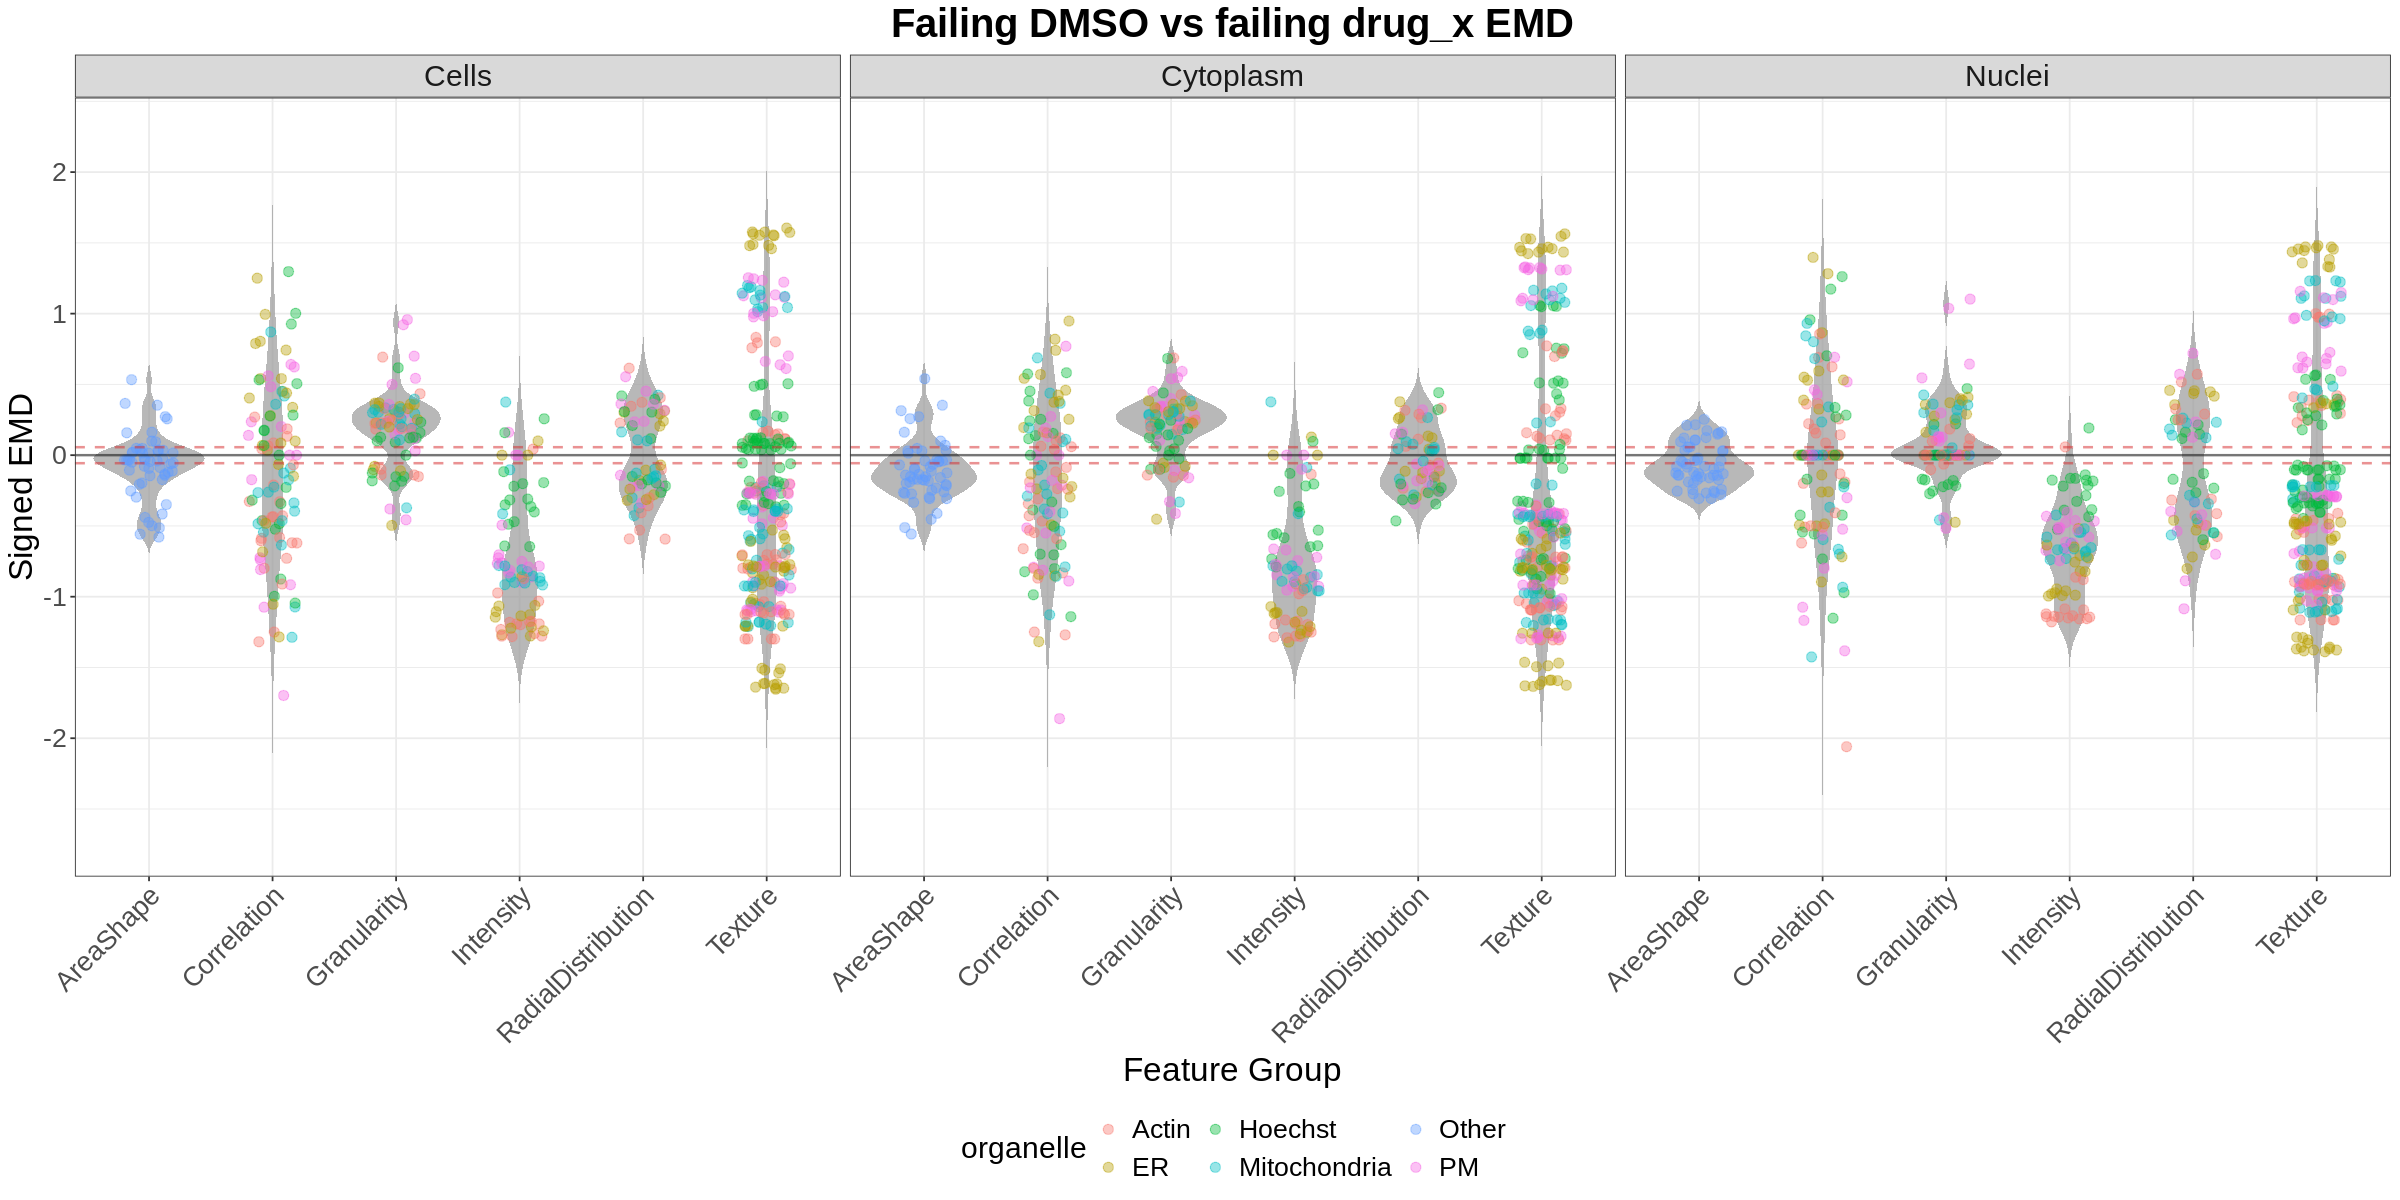

In [5]:
height <- 10
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

failing_vs_failing_drug_x_plot <- ggplot(failing_vs_failing_drug_x_emd_df, aes(x = feature_group, y = signed_emd)) +
    geom_violin(trim = FALSE, fill = "grey60", color = NA, alpha = 0.7) +
    geom_jitter(aes(color = organelle), width = 0.2, alpha = 0.4, size = 2.5) +
    geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.7, alpha = 0.5) +
    geom_hline(yintercept = emd_positive_threshold, linetype = "dashed", color = "#D62728", size = 0.7, alpha = 0.5) +
    geom_hline(yintercept = emd_negative_threshold, linetype = "dashed", color = "#D62728", size = 0.7, alpha = 0.5) +
    facet_wrap(~ compartment) +
    theme_bw() +
    labs(
        title = "Failing DMSO vs failing drug_x EMD",
        x = "Feature Group",
        y = "Signed EMD"
    ) +
    theme(
        legend.position = "bottom",
        plot.title = element_text(size = 24, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 18),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_failing_drug_x_emd_violin_plot.png"),
    plot = failing_vs_failing_drug_x_plot,
    width = width,
    height = height,
    dpi = 500
)

failing_vs_failing_drug_x_plot

In [6]:
emd_direction_fraction <- failing_vs_failing_drug_x_emd_df %>%
  mutate(direction = case_when(
    signed_emd > emd_positive_threshold ~ "increased",
    signed_emd < emd_negative_threshold ~ "decreased",
    TRUE ~ "no change"
  )) %>%
  group_by(feature_group, organelle, direction) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(feature_group, organelle) %>%
  mutate(fraction = count / sum(count)) %>%
  ungroup()


head(emd_direction_fraction)

feature_group,organelle,direction,count,fraction
<chr>,<chr>,<chr>,<int>,<dbl>
AreaShape,Other,decreased,89,0.54938272
AreaShape,Other,increased,30,0.18518519
AreaShape,Other,no change,43,0.26543210
Correlation,Actin,decreased,45,0.62500000
Correlation,Actin,increased,21,0.29166667
Correlation,Actin,no change,6,0.08333333


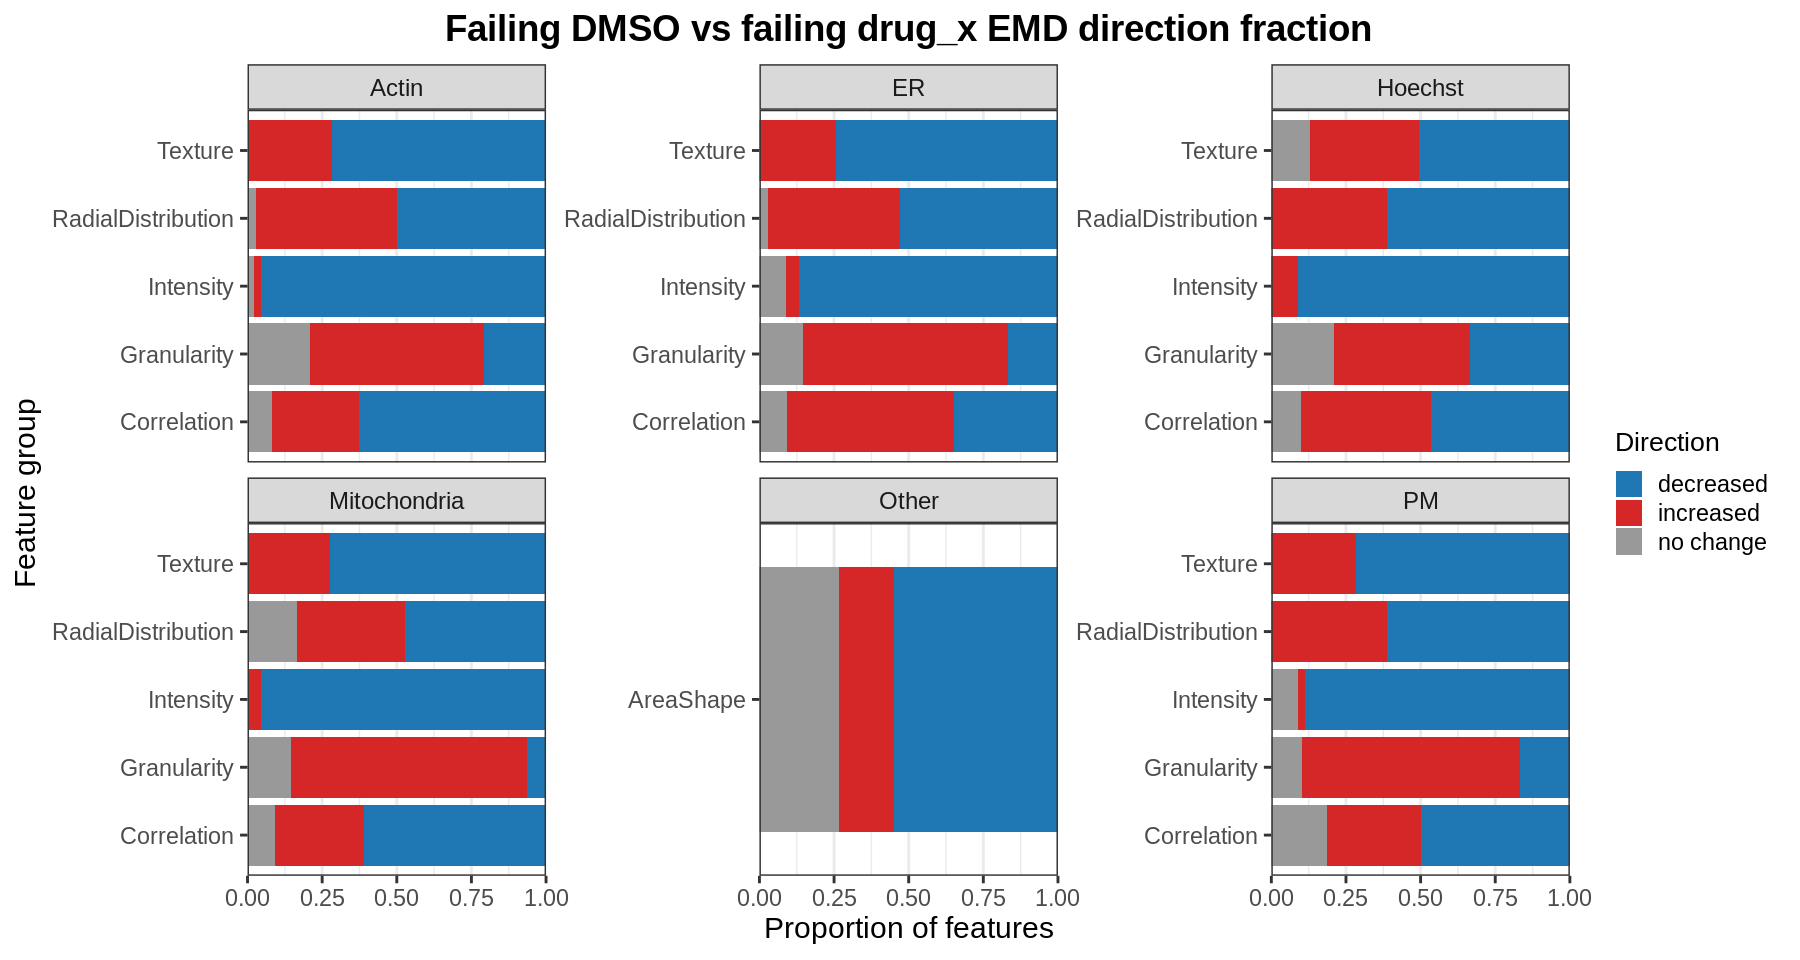

In [7]:
height <- 8
width <- 15
options(repr.plot.width = width, repr.plot.height = height)

emd_direction_fraction_plot <- ggplot(emd_direction_fraction, aes(x = fraction, y = feature_group, fill = direction)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    labs(
        title = "Failing DMSO vs failing drug_x EMD direction fraction",
        x = "Proportion of features",
        y = "Feature group",
        fill = "Direction"
    ) +
    facet_wrap(~ organelle, scales = "free_y") +
    theme_bw(base_size = 18) +
    scale_fill_manual(
    values = c(
        "increased" = "#D62728",  # red
        "decreased" = "#1F77B4",  # blue
        "no change" = "grey60"
        )
    ) +
    theme(
        plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 18),
        axis.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        legend.text = element_text(size = 14)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_failing_drug_x_emd_fraction_bar_plot.png"),
    plot = emd_direction_fraction_plot,
    width = width,
    height = height,
    dpi = 500
)

emd_direction_fraction_plot

## Visualize healthy DMSO cells (reference) compared to failing drug_x cells

In [8]:
healthy_vs_failing_drug_x_emd_df <- read_parquet("emd_results/healthy_vs_failing_drug_x_emd.parquet")

# Set thresholds for EMD values that represent "no change"
emd_positive_threshold <- emd_upper_threshold_healthy_v_failing_drug_x
emd_negative_threshold <- emd_lower_threshold_healthy_v_failing_drug_x

dim(healthy_vs_failing_drug_x_emd_df)
head(healthy_vs_failing_drug_x_emd_df)

[1] 1887    6

feature,signed_emd,compartment,feature_group,measurement,organelle
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Cytoplasm_AreaShape_Area,0.11387851,Cytoplasm,AreaShape,Area,Other
Cytoplasm_AreaShape_BoundingBoxArea,0.36078573,Cytoplasm,AreaShape,BoundingBoxArea,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_X,0.07507932,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,0.12354190,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_X,0.06942761,Cytoplasm,AreaShape,BoundingBoxMinimum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,0.14964953,Cytoplasm,AreaShape,BoundingBoxMinimum,Other


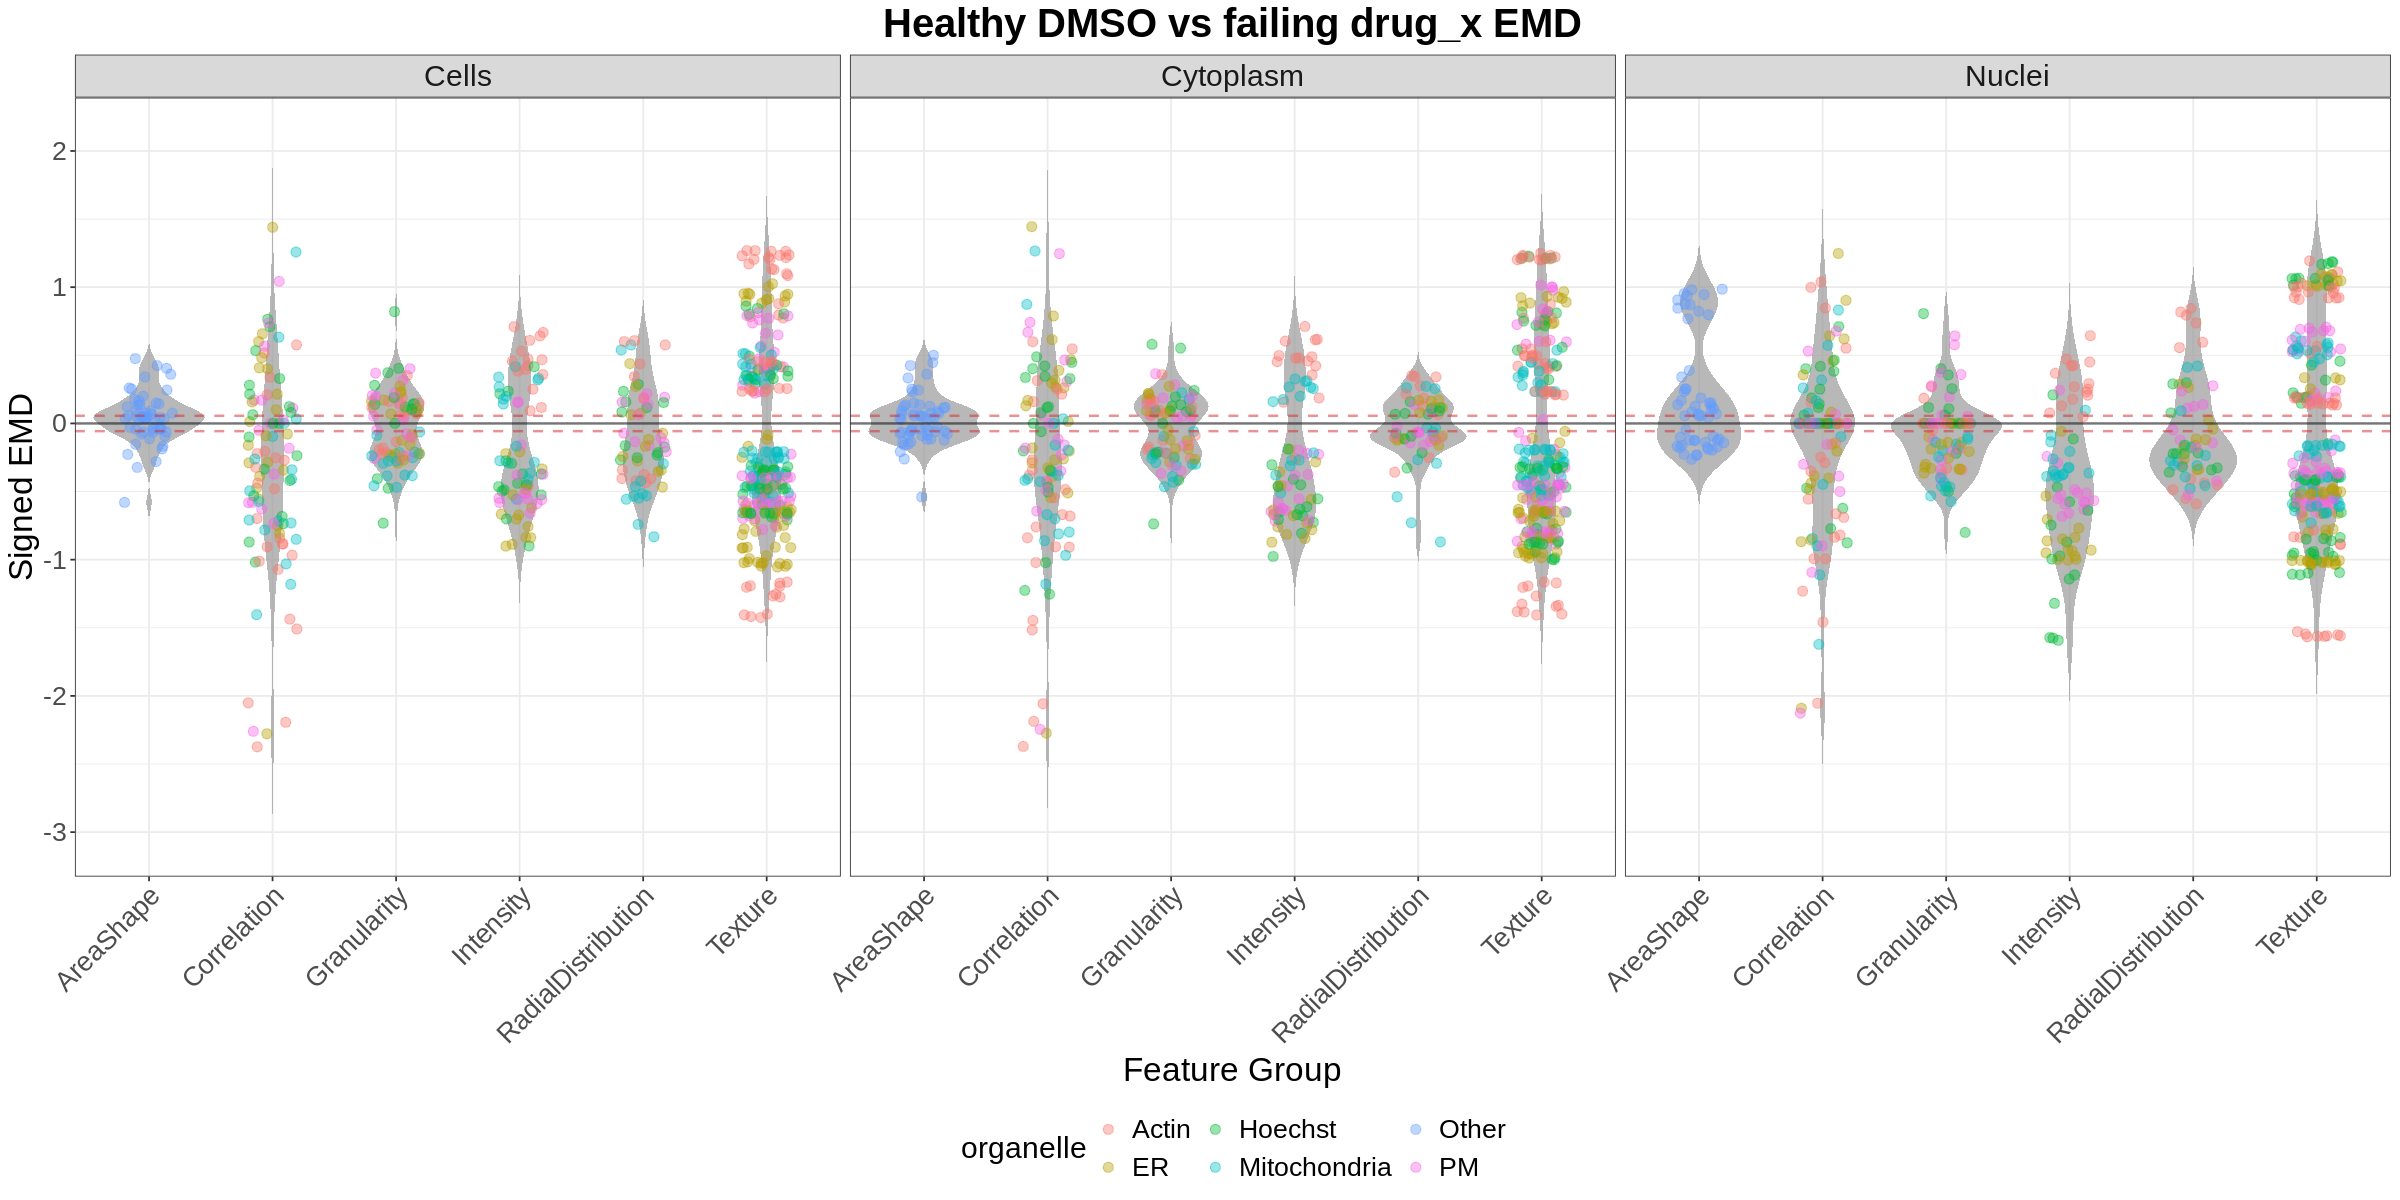

In [9]:
height <- 10
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

healthy_vs_failing_drug_x_plot <- ggplot(healthy_vs_failing_drug_x_emd_df, aes(x = feature_group, y = signed_emd)) +
    geom_violin(trim = FALSE, fill = "grey60", color = NA, alpha = 0.7) +
    geom_jitter(aes(color = organelle), width = 0.2, alpha = 0.4, size = 2.5) +
    geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.7, alpha = 0.5) +
    geom_hline(yintercept = emd_positive_threshold, linetype = "dashed", color = "#D62728", size = 0.7, alpha = 0.5) +
    geom_hline(yintercept = emd_negative_threshold, linetype = "dashed", color = "#D62728", size = 0.7, alpha = 0.5) +
    facet_wrap(~ compartment) +
    theme_bw() +
    labs(
        title = "Healthy DMSO vs failing drug_x EMD",
        x = "Feature Group",
        y = "Signed EMD"
    ) +
    theme(
        legend.position = "bottom",
        plot.title = element_text(size = 24, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 18),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "healthy_vs_failing_drug_x_emd_violin_plot.png"),
    plot = healthy_vs_failing_drug_x_plot,
    width = width,
    height = height,
    dpi = 500
)

healthy_vs_failing_drug_x_plot

In [10]:
hvf_emd_direction_fraction <- healthy_vs_failing_drug_x_emd_df %>%
  mutate(direction = case_when(
    signed_emd > emd_positive_threshold ~ "increased",
    signed_emd < emd_negative_threshold ~ "decreased",
    TRUE ~ "no change"
  )) %>%
  group_by(feature_group, organelle, direction) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(feature_group, organelle) %>%
  mutate(fraction = count / sum(count)) %>%
  ungroup()


head(hvf_emd_direction_fraction)

feature_group,organelle,direction,count,fraction
<chr>,<chr>,<chr>,<int>,<dbl>
AreaShape,Other,decreased,52,0.32098765
AreaShape,Other,increased,75,0.46296296
AreaShape,Other,no change,35,0.21604938
Correlation,Actin,decreased,52,0.72222222
Correlation,Actin,increased,15,0.20833333
Correlation,Actin,no change,5,0.06944444


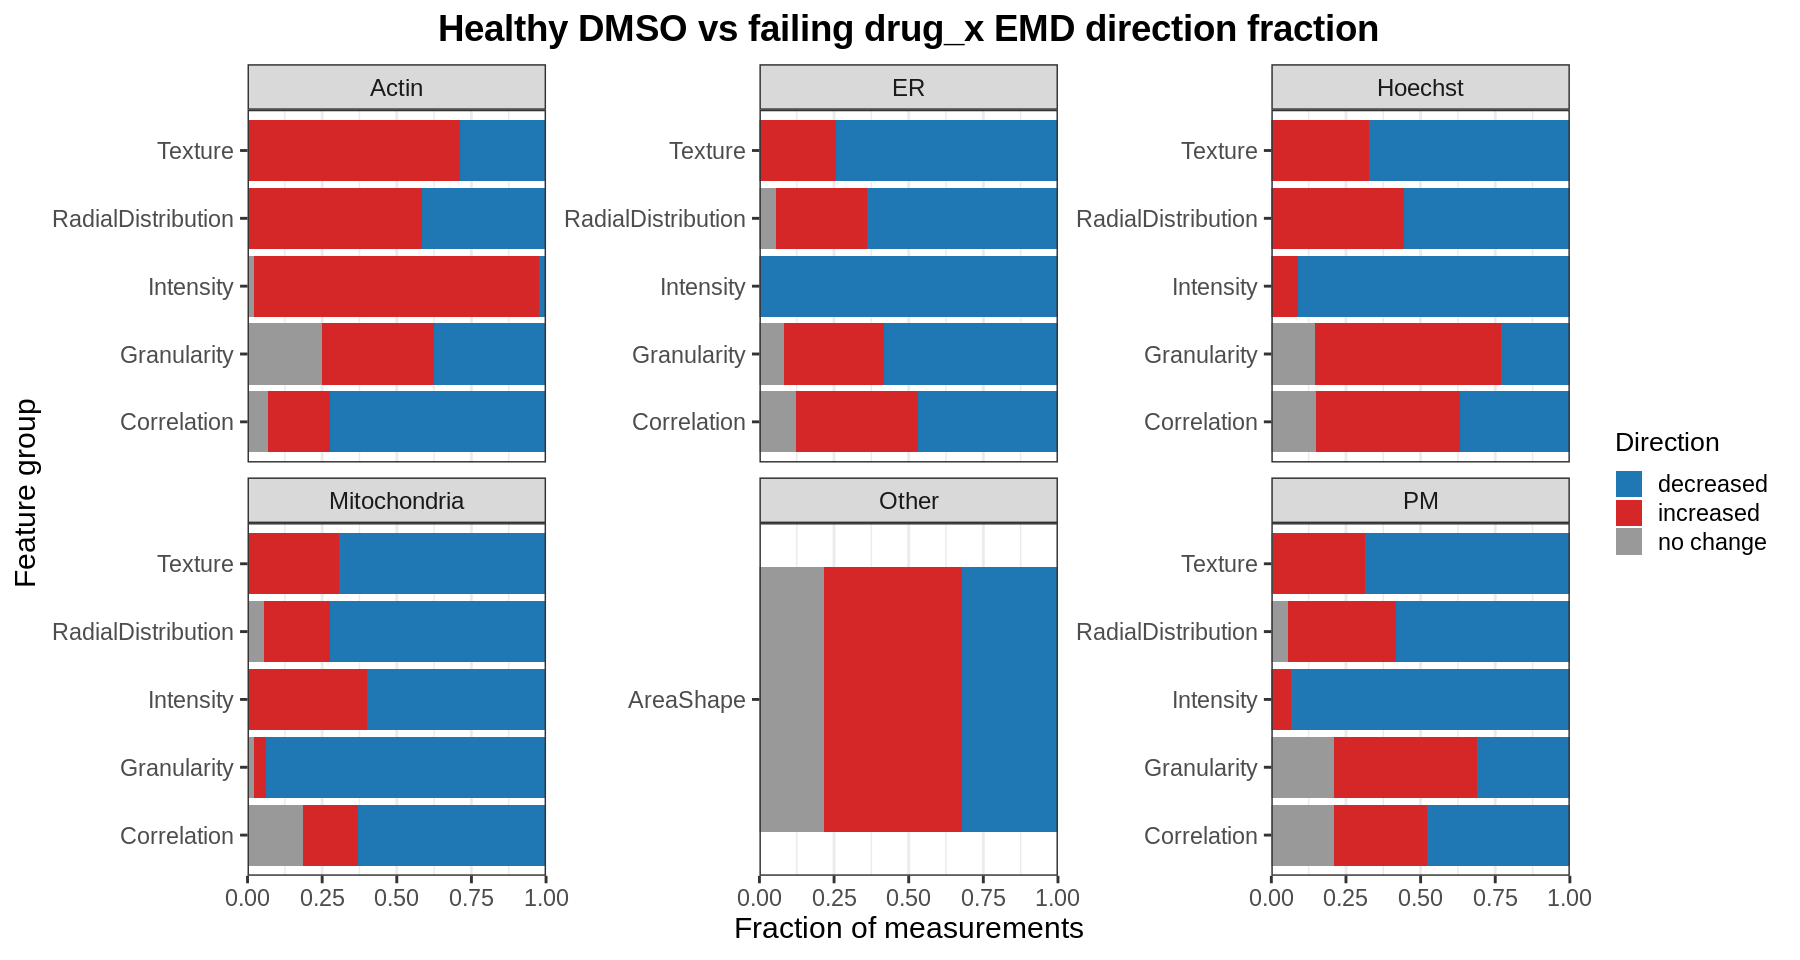

In [11]:
height <- 8
width <- 15
options(repr.plot.width = width, repr.plot.height = height)

hvf_emd_direction_fraction_plot <- ggplot(hvf_emd_direction_fraction, aes(x = fraction, y = feature_group, fill = direction)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    labs(
        title = "Healthy DMSO vs failing drug_x EMD direction fraction",
        x = "Fraction of measurements",
        y = "Feature group",
        fill = "Direction"
    ) +
    facet_wrap(~ organelle, scales = "free_y") +
    theme_bw(base_size = 18) +
    scale_fill_manual(
    values = c(
        "increased" = "#D62728",  # red
        "decreased" = "#1F77B4",  # blue
        "no change" = "grey60"
        )
    ) +
    theme(
        plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 18),
        axis.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        legend.text = element_text(size = 14)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "healthy_vs_failing_drug_x_emd_fraction_bar_plot.png"),
    plot = hvf_emd_direction_fraction_plot,
    width = width,
    height = height,
    dpi = 500
)

hvf_emd_direction_fraction_plot

## Visualize failing DMSO cells (reference) compared to healthy DMSO cells

In [12]:
failing_vs_healthy_DMSO_emd_df <- read_parquet("emd_results/failing_vs_healthy_DMSO_emd.parquet")

# Set thresholds for EMD values that represent "no change"
emd_positive_threshold <- emd_upper_threshold_failing_v_healthy_DMSO
emd_negative_threshold <- emd_lower_threshold_failing_v_healthy_DMSO

dim(failing_vs_healthy_DMSO_emd_df)
head(failing_vs_healthy_DMSO_emd_df)

[1] 1887    6

feature,signed_emd,compartment,feature_group,measurement,organelle
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Cytoplasm_AreaShape_Area,-0.15172402,Cytoplasm,AreaShape,Area,Other
Cytoplasm_AreaShape_BoundingBoxArea,0.42672994,Cytoplasm,AreaShape,BoundingBoxArea,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_X,-0.04893365,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,-0.07852257,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_X,-0.09361491,Cytoplasm,AreaShape,BoundingBoxMinimum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,-0.13768409,Cytoplasm,AreaShape,BoundingBoxMinimum,Other


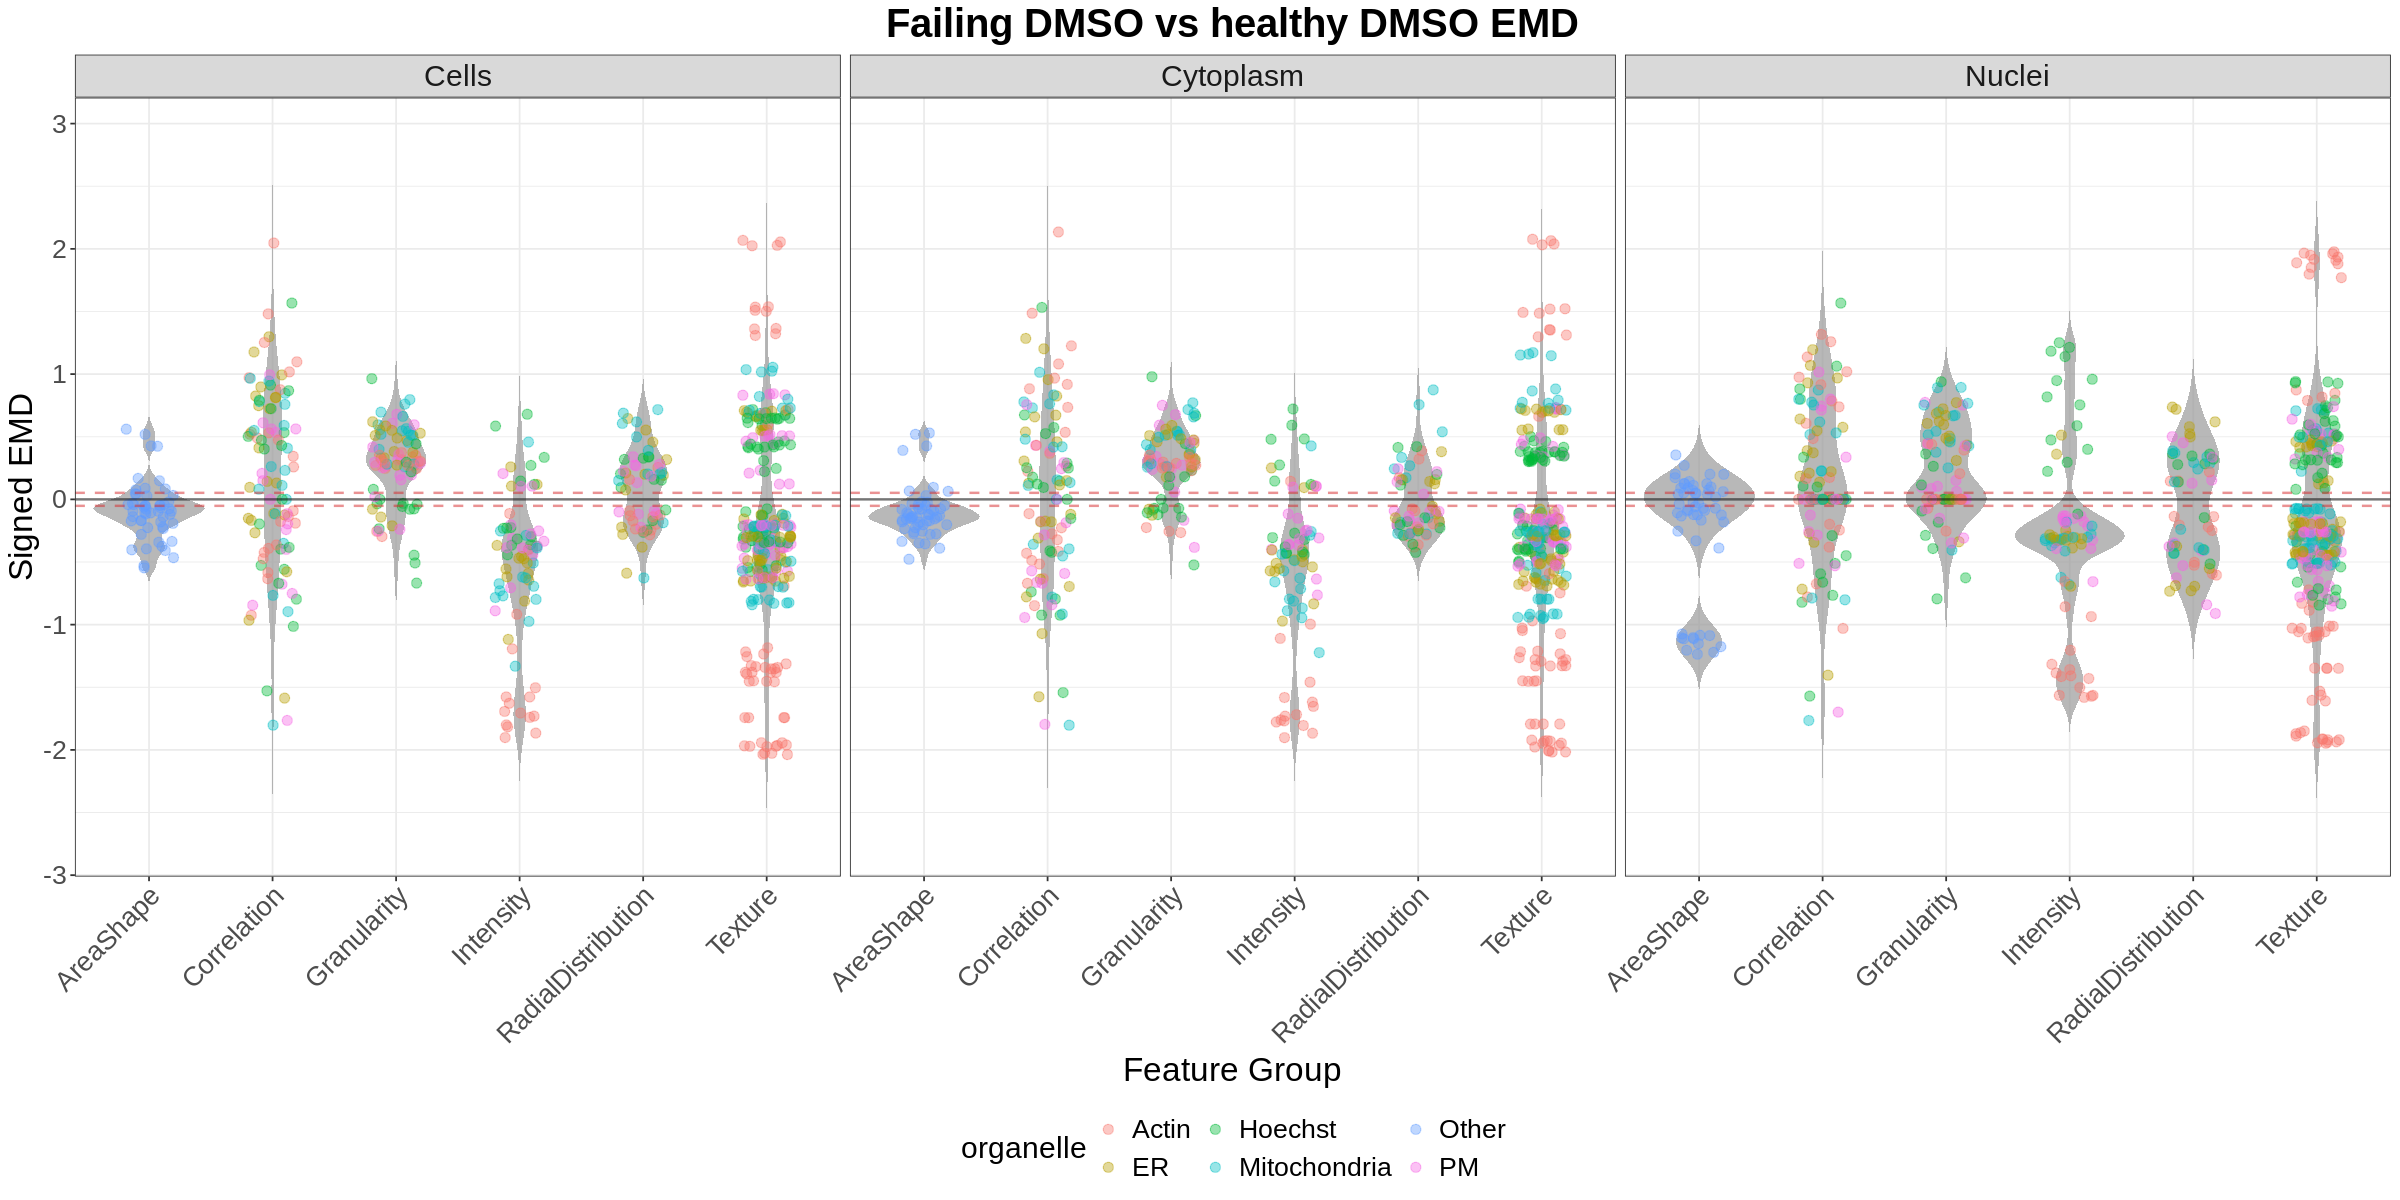

In [13]:
height <- 10
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

failing_vs_healthy_DMSO_plot <- ggplot(failing_vs_healthy_DMSO_emd_df, aes(x = feature_group, y = signed_emd)) +
    geom_violin(trim = FALSE, fill = "grey60", color = NA, alpha = 0.7) +
    geom_jitter(aes(color = organelle), width = 0.2, alpha = 0.4, size = 2.5) +
    geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.7, alpha = 0.5) +
    geom_hline(yintercept = emd_positive_threshold, linetype = "dashed", color = "#D62728", size = 0.7, alpha = 0.5) +
    geom_hline(yintercept = emd_negative_threshold, linetype = "dashed", color = "#D62728", size = 0.7, alpha = 0.5) +
    facet_wrap(~ compartment) +
    theme_bw() +
    labs(
        title = "Failing DMSO vs healthy DMSO EMD",
        x = "Feature Group",
        y = "Signed EMD"
    ) +
    theme(
        legend.position = "bottom",
        plot.title = element_text(size = 24, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 18),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_healthy_DMSO_emd_violin_plot.png"),
    plot = failing_vs_healthy_DMSO_plot,
    width = width,
    height = height,
    dpi = 500
)

failing_vs_healthy_DMSO_plot

In [14]:
fvh_emd_direction_fraction <- failing_vs_healthy_DMSO_emd_df %>%
  mutate(direction = case_when(
    signed_emd > emd_positive_threshold ~ "increased",
    signed_emd < emd_negative_threshold ~ "decreased",
    TRUE ~ "no change"
  )) %>%
  group_by(feature_group, organelle, direction) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(feature_group, organelle) %>%
  mutate(fraction = count / sum(count)) %>%
  ungroup()


head(fvh_emd_direction_fraction)

feature_group,organelle,direction,count,fraction
<chr>,<chr>,<chr>,<int>,<dbl>
AreaShape,Other,decreased,100,0.61728395
AreaShape,Other,increased,33,0.20370370
AreaShape,Other,no change,29,0.17901235
Correlation,Actin,decreased,28,0.38888889
Correlation,Actin,increased,38,0.52777778
Correlation,Actin,no change,6,0.08333333


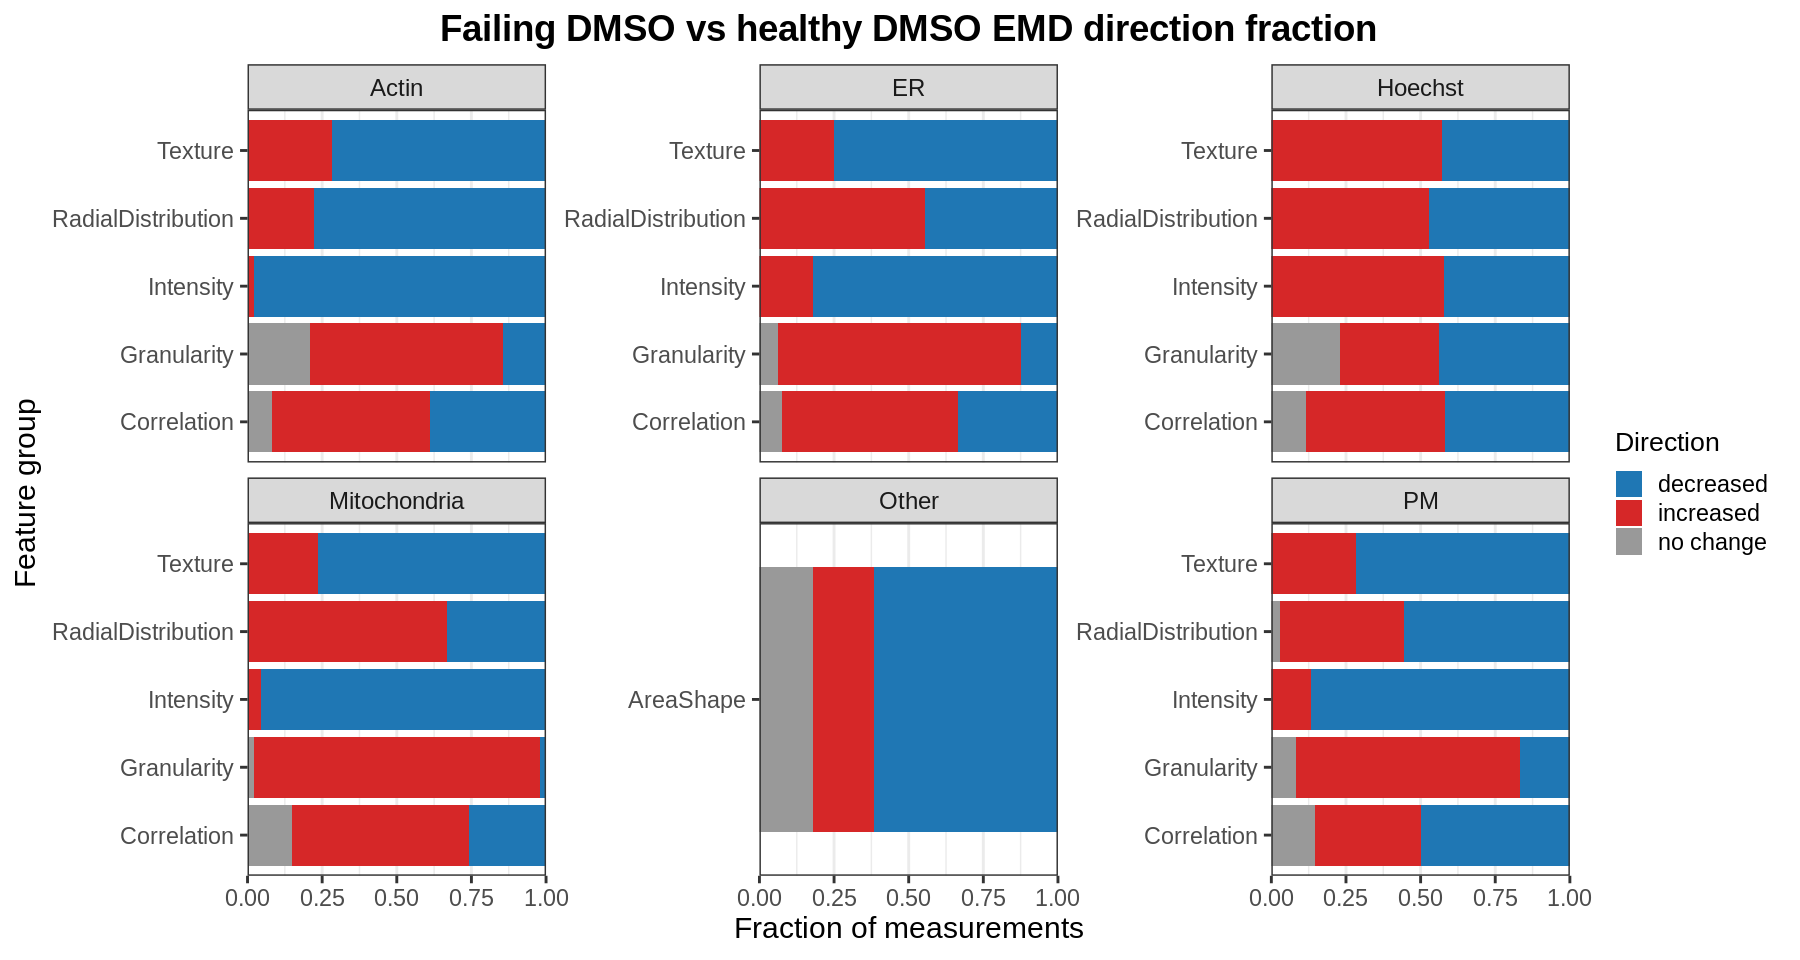

In [15]:
height <- 8
width <- 15
options(repr.plot.width = width, repr.plot.height = height)

fvh_emd_direction_fraction_plot <- ggplot(fvh_emd_direction_fraction, aes(x = fraction, y = feature_group, fill = direction)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    labs(
        title = "Failing DMSO vs healthy DMSO EMD direction fraction",
        x = "Fraction of measurements",
        y = "Feature group",
        fill = "Direction"
    ) +
    facet_wrap(~ organelle, scales = "free_y") +
    theme_bw(base_size = 18) +
    scale_fill_manual(
    values = c(
        "increased" = "#D62728",  # red
        "decreased" = "#1F77B4",  # blue
        "no change" = "grey60"
        )
    ) +
    theme(
        plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 18),
        axis.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        legend.text = element_text(size = 14)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_healthy_DMSO_emd_fraction_bar_plot.png"),
    plot = fvh_emd_direction_fraction_plot,
    width = width,
    height = height,
    dpi = 500
)

fvh_emd_direction_fraction_plot